In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Importing library
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
import numpy as np

In [3]:
################CREATING AND COMPILING ALEXNET MODEL ########################
#Instantiate an empty model
model = Sequential()
# 1st Convolutional Layer
#model.add(Conv2D(filters=96, input_shape=(224,224,3), kernel_size=(11,11), \
#                 strides=(4,4), padding='valid'))
model.add(Conv2D(filters=46, input_shape=(224,224,3), kernel_size=(11,11), \
                 strides=(4,4), padding='valid'))
model.add(Activation('relu'))
# Max Pooling
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))
model.add(BatchNormalization())
# 2nd Convolutional Layer
#model.add(Conv2D(filters=256, kernel_size=(11,11), strides=(1,1), \
#                 padding='valid'))
model.add(Conv2D(filters=123, kernel_size=(11,11), strides=(1,1), \
                 padding='valid'))
model.add(Activation('relu'))
# Max Pooling
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))
model.add(BatchNormalization())
# 3rd Convolutional Layer
#model.add(Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), \
#                 padding='valid'))
model.add(Conv2D(filters=184, kernel_size=(3,3), strides=(1,1), \
                 padding='valid'))
model.add(Activation('relu'))
model.add(BatchNormalization())
# 4th Convolutional Layer
#model.add(Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), \
 #                padding='valid'))
model.add(Conv2D(filters=184, kernel_size=(3,3), strides=(1,1), \
                 padding='valid'))
model.add(Activation('relu'))
model.add(BatchNormalization())
# 5th Convolutional Layer
#model.add(Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), \
#                 padding='valid'))
model.add(Conv2D(filters=123, kernel_size=(3,3), strides=(1,1), \
                 padding='valid'))
model.add(Activation('relu'))
# Max Pooling
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))
model.add(BatchNormalization())
# Passing it to a Fully Connected layer
model.add(Flatten())
# 1st Fully Connected Layer
#model.add(Dense(4096, input_shape=(224*224*3,)))
model.add(Dense(1952, input_shape=(224*224*3,)))
model.add(Activation('relu'))
# Add Dropout to prevent overfitting
model.add(Dropout(0.4))
# 2nd Fully Connected Layer
#model.add(Dense(4096))
model.add(Dense(1952))
model.add(Activation('relu'))
# Add Dropout
model.add(Dropout(0.4))
model.add(BatchNormalization())
# 3rd Fully Connected Layer
#model.add(Dense(1000))
model.add(Dense(600))
model.add(Activation('relu'))

# Add Dropout
model.add(Dropout(0.4))
model.add(BatchNormalization())
# Output Layer
model.add(Dense(2))
model.add(Activation('softmax'))
model.summary()

# Compile the model
model.compile(loss=keras.losses.sparse_categorical_crossentropy, optimizer='adam', metrics=["accuracy"])


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 54, 54, 46)        16744     
                                                                 
 activation (Activation)     (None, 54, 54, 46)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 27, 27, 46)       0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 27, 27, 46)       184       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 17, 17, 123)       684741    
                                                                 
 activation_1 (Activation)   (None, 17, 17, 123)       0

In [5]:
######generating INPUT DATA IMAGES 
from keras.preprocessing.image import ImageDataGenerator
# create a data generator
import tensorflow as tf
#datagen =  tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=20,
#   zoom_range=0.15,
#   width_shift_range=0.2,
#   height_shift_range=0.2,
#   shear_range=0.15,
#   horizontal_flip=True,
#   fill_mode="nearest")
train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)
# load and iterate training dataset
#datagen.fit(augment=True)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator= train_datagen.flow_from_directory("/content/drive/MyDrive/real_and_fake_face/training",
        target_size=(224, 224),
        batch_size=64,
        class_mode='binary')
# load and iterate validation dataset
validation_generator= test_datagen.flow_from_directory(\
      "/content/drive/MyDrive/real_and_fake_face/testing",target_size=(224, 224),
        batch_size=64,
        class_mode='binary')
# load and iterate testing dataset
#test_generator= datagen.flow_from_directory(\
 #     "/content/drive/MyDrive/rice_leaf_diseases/Test",target_size=(224, 224),
  #      batch_size=5,
   #     class_mode='binary')
model.fit_generator(
      train_generator,
      steps_per_epoch=train_generator.samples//64,
      epochs=40,verbose=1,
      shuffle=True,
      validation_data=validation_generator,
      validation_steps=validation_generator.samples //64)
hist=model.evaluate_generator(
      validation_generator,
      steps=10,verbose=1)
print(model.metrics_names)
print(hist)


Found 1653 images belonging to 2 classes.
Found 408 images belonging to 2 classes.


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:39: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.


Epoch 1/40
25/25 [==============================] - 46s 2s/step - loss: 1.0379 - accuracy: 0.5063 - val_loss: 7.0917 - val_accuracy: 0.4766
Epoch 2/40
25/25 [==============================] - 45s 2s/step - loss: 0.8947 - accuracy: 0.5098 - val_loss: 1.0913 - val_accuracy: 0.4661
Epoch 3/40
25/25 [==============================] - 45s 2s/step - loss: 0.8216 - accuracy: 0.5104 - val_loss: 0.7863 - val_accuracy: 0.5391
Epoch 4/40
25/25 [==============================] - 45s 2s/step - loss: 0.7636 - accuracy: 0.5557 - val_loss: 0.9066 - val_accuracy: 0.5599
Epoch 5/40
25/25 [==============================] - 44s 2s/step - loss: 0.7461 - accuracy: 0.5878 - val_loss: 0.9044 - val_accuracy: 0.5521
Epoch 6/40
25/25 [==============================] - 44s 2s/step - loss: 0.7496 - accuracy: 0.5802 - val_loss: 0.7730 - val_accuracy: 0.5573
Epoch 7/40
25/25 [==============================] - 45s 2s/step - loss: 0.7214 - accuracy: 0.6010 - val_loss: 0.7710 - val_accuracy: 0.5807
Epoch 8/40
25/25 [==

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:42: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.


10/10 [==============================] - 6s 560ms/step - loss: 0.8865 - accuracy: 0.6176
['loss', 'accuracy']
[0.8864609003067017, 0.6176470518112183]


In [7]:
import pickle
with open("/content/drive/MyDrive/Alexnetfake","wb") as f:
  pickle.dump(model,f)

INFO:tensorflow:Assets written to: ram://ff8197d7-825d-4636-97e6-7a7d8a057d1a/assets


In [13]:
with open("/content/drive/MyDrive/Alexnetfake","rb") as f:
  al=pickle.load(f)

In [28]:
from tensorflow.keras.preprocessing import image
img = image.load_img("/content/drive/MyDrive/real_and_fake_face/testing/testing_real/real_00891.jpg", target_size=(224, 224))
img_array = image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)
#img_preprocessed = preprocess_input(img_batch)
#model = tf.keras.applications.resnet50.ResNet50()
prediction = model.predict(img_batch)
print(prediction[0])

[0. 1.]


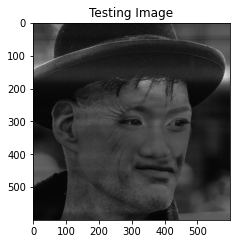

In [25]:
plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img[:,:,0], cmap='gray')